# Machine Learning 1 - Steel Plates Fault Classification

## Model Classification

**Nama:** Bartholomeus Mack Theo Sinaga  
**Role:** ML Engineer 1  
**Dataset:** Steel Plates Faults

### Tujuan

Membangun model Machine Learning supervised untuk melakukan klasifikasi
jenis kerusakan pada steel plate berdasarkan feature hasil preprocessing
Data Engineer.

### Tahapan

1. Load dataset training dan testing
2. Pemeriksaan data
3. Pemisahan feature dan target
4. Feature scaling
5. Training beberapa model classification
6. Evaluasi model
7. Perbandingan hasil model
8. Pemilihan model berdasarkan metrik evaluasi
9. Training final model
10. Penyimpanan model untuk digunakan oleh backend

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Library berhasil di-import.")

Library berhasil di-import.


In [3]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

print("Training dataset:", train_df.shape)
print("Testing dataset :", test_df.shape)

Training dataset: (1552, 30)
Testing dataset : (389, 30)


In [4]:
X_train = train_df.drop(columns=["Defect_Type"])
y_train = train_df["Defect_Type"]

X_test = test_df.drop(columns=["Defect_Type"])
y_test = test_df["Defect_Type"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (1552, 29)
y_train: (1552,)
X_test : (389, 29)
y_test : (389,)


In [5]:
scaler = joblib.load("../models/standard_scaler.pkl")

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling berhasil.")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

Scaling berhasil.
X_train_scaled: (1552, 29)
X_test_scaled : (389, 29)


c:\Users\Lenovo\anaconda3\envs\ml_env\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


##  Training Classification Models

Beberapa algoritma classification digunakan untuk membandingkan
performa model pada dataset Steel Plates Faults.

Model yang digunakan:

1. Logistic Regression
2. Random Forest
3. K-Nearest Neighbors
4. Support Vector Machine

In [6]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        kernel="rbf",
        random_state=42
    )
}

print("Model yang akan diuji:")

for name in models:
    print("-", name)

Model yang akan diuji:
- Logistic Regression
- Random Forest
- KNN
- SVM


In [7]:
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(
        X_train_scaled,
        y_train
    )

    trained_models[name] = model

    print(f"{name} selesai.")


Training Logistic Regression...
Logistic Regression selesai.

Training Random Forest...
Random Forest selesai.

Training KNN...
KNN selesai.

Training SVM...
SVM selesai.


##  Classification Report

Classification report digunakan untuk melihat performa Random Forest
pada masing-masing kelas berdasarkan precision, recall, dan F1-score.

Evaluasi per kelas penting karena dataset memiliki distribusi kelas
yang tidak seimbang.

In [16]:
rf_model = trained_models["Random Forest"]

y_pred_rf = rf_model.predict(X_test_scaled)

print("Classification Report - Random Forest")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, zero_division=0))

Classification Report - Random Forest
              precision    recall  f1-score   support

       Bumps       0.72      0.69      0.70        81
   Dirtiness       0.82      0.82      0.82        11
    K_Scatch       0.97      0.90      0.93        78
Other_Faults       0.71      0.83      0.77       135
      Pastry       0.74      0.53      0.62        32
      Stains       0.92      0.86      0.89        14
   Z_Scratch       0.97      0.89      0.93        38

    accuracy                           0.80       389
   macro avg       0.84      0.79      0.81       389
weighted avg       0.80      0.80      0.80       389



## Confusion Matrix

Confusion matrix digunakan untuk melihat distribusi prediksi benar
dan kesalahan klasifikasi pada setiap kelas.

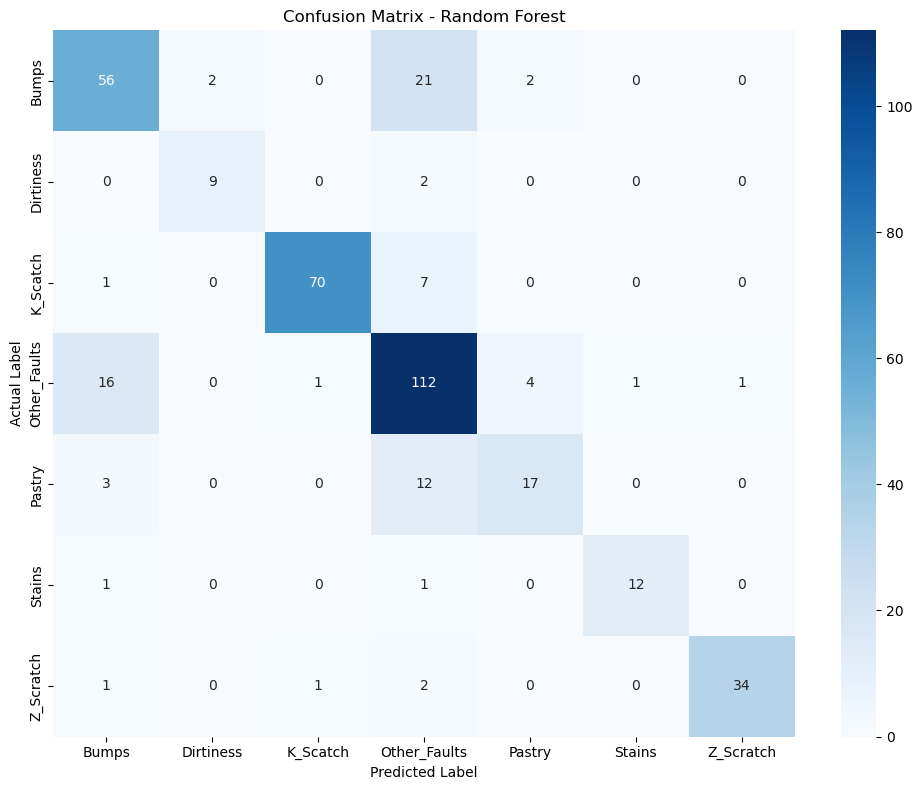

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=rf_model.classes_
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

##  Feature Importance

Feature importance digunakan untuk melihat fitur yang paling berkontribusi
dalam proses pengambilan keputusan Random Forest.

In [18]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
10,Length_of_Conveyer,0.059972
22,Log_X_Index,0.053134
21,LogOfAreas,0.049961
4,Pixels_Areas,0.047633
13,Steel_Plate_Thickness,0.047547
27,Defect_Width,0.044968
7,Sum_of_Luminosity,0.044407
8,Minimum_of_Luminosity,0.044078
1,X_Maximum,0.039602
17,Outside_X_Index,0.039398


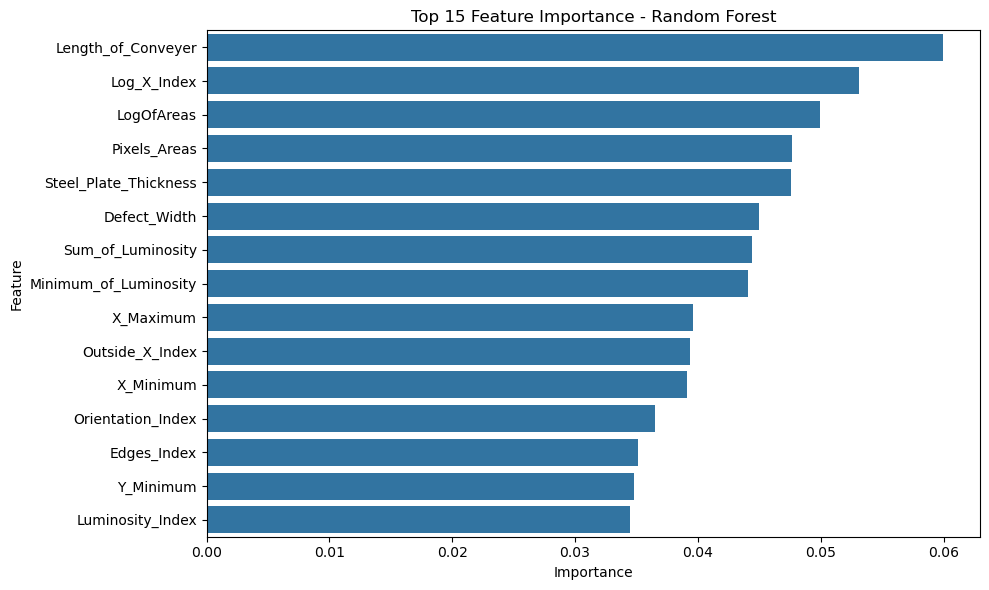

In [19]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##  Analysis

Random Forest menghasilkan performa yang lebih tinggi dibandingkan model
lain yang diuji berdasarkan accuracy, precision macro, recall macro,
dan F1 macro.

Pada evaluasi per kelas, K_Scatch dan Z_Scratch memiliki recall yang
tinggi. Sementara itu, kelas Pastry memiliki recall yang lebih rendah,
sehingga masih terdapat kesalahan klasifikasi pada kelas tersebut.

Confusion matrix menunjukkan bahwa sebagian data Pastry diprediksi sebagai
Other_Faults.

Feature importance menunjukkan bahwa Length_of_Conveyer, Log_X_Index,
LogOfAreas, dan Pixels_Areas termasuk fitur dengan kontribusi terbesar
dalam model Random Forest.

Karena dataset memiliki distribusi kelas yang tidak seimbang, F1 Macro
digunakan sebagai salah satu metrik utama untuk evaluasi.

##  Hyperparameter Tuning

Hyperparameter tuning dilakukan untuk mencari konfigurasi Random Forest
yang memberikan performa lebih baik.

Parameter yang diuji meliputi:

- `n_estimators`: jumlah decision tree
- `max_depth`: kedalaman maksimum tree
- `min_samples_split`: jumlah minimum sample untuk melakukan split
- `min_samples_leaf`: jumlah minimum sample pada leaf

Evaluasi menggunakan F1 Macro karena dataset memiliki distribusi kelas
yang tidak seimbang.

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 Macro:")
print(grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best CV F1 Macro:
0.7931306594896685


In [21]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_scaled)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    average="macro",
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    average="macro",
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    average="macro",
    zero_division=0
)

print("Tuned Random Forest")
print("=" * 40)
print("Accuracy        :", tuned_accuracy)
print("Precision Macro :", tuned_precision)
print("Recall Macro    :", tuned_recall)
print("F1 Macro        :", tuned_f1)

Tuned Random Forest
Accuracy        : 0.7969151670951157
Precision Macro : 0.8325850911407296
Recall Macro    : 0.7851274966563186
F1 Macro        : 0.8051160501012617


In [22]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1 Macro"
    ],
    "Before Tuning": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf, average="macro", zero_division=0),
        recall_score(y_test, y_pred_rf, average="macro", zero_division=0),
        f1_score(y_test, y_pred_rf, average="macro", zero_division=0)
    ],
    "After Tuning": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

comparison

,Metric,Before Tuning,After Tuning
0,Accuracy,0.796915,0.796915
1,Precision Macro,0.836481,0.832585
2,Recall Macro,0.788534,0.785127
3,F1 Macro,0.808803,0.805116


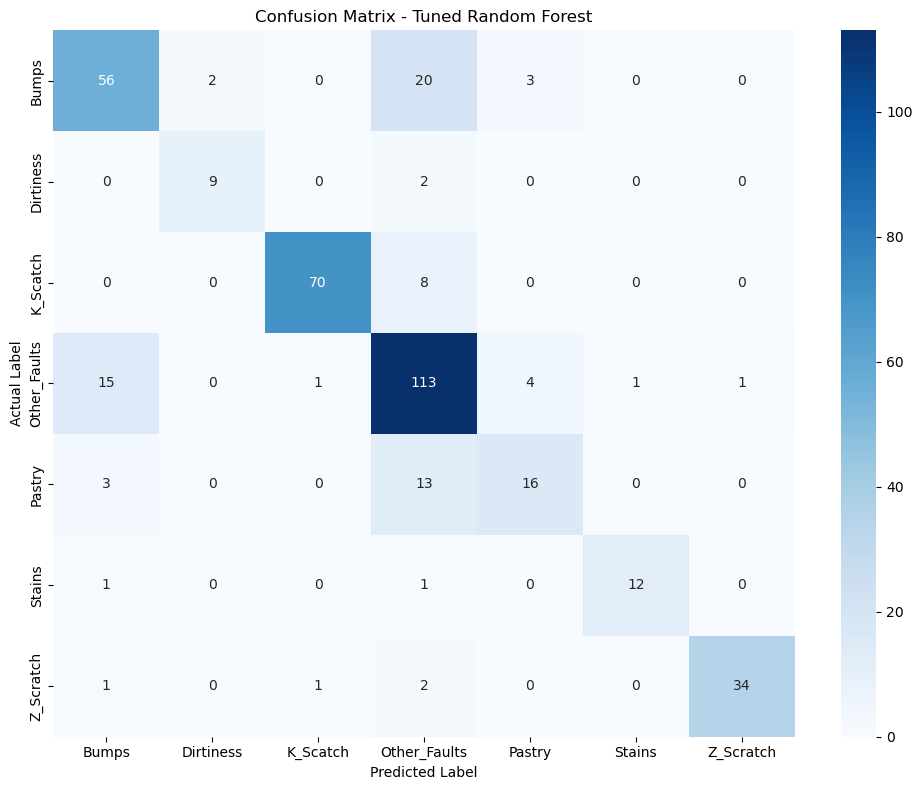

In [23]:
cm_final = confusion_matrix(
    y_test,
    y_pred_tuned,
    labels=best_rf.classes_
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_rf.classes_,
    yticklabels=best_rf.classes_
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [24]:
joblib.dump(
    best_rf,
    "../models/random_forest_model.pkl"
)

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [25]:
final_results = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "Accuracy": [tuned_accuracy],
    "Precision_Macro": [tuned_precision],
    "Recall_Macro": [tuned_recall],
    "F1_Macro": [tuned_f1]
})

final_results.to_csv(
    "../models/final_classification_results.csv",
    index=False
)

final_results

,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
0,Tuned Random Forest,0.796915,0.832585,0.785127,0.805116


## Conclusion

Pada tahap ML1, dilakukan pembangunan model supervised learning untuk
mengklasifikasikan jenis defect pada Steel Plates Faults Dataset.

Data training dan testing dipisahkan menjadi fitur dan target, kemudian
fitur dinormalisasi menggunakan StandardScaler yang telah disiapkan pada
tahap preprocessing. Empat algoritma klasifikasi dibandingkan, yaitu
Logistic Regression, Random Forest, KNN, dan SVM.

Berdasarkan evaluasi awal pada test set, Random Forest menghasilkan
accuracy sebesar 0.7969 dan F1 Macro sebesar 0.8088. Model ini kemudian
dianalisis lebih lanjut menggunakan classification report, confusion
matrix, dan feature importance.

Selanjutnya dilakukan hyperparameter tuning menggunakan GridSearchCV
dengan 5-fold cross-validation dan F1 Macro sebagai scoring. Konfigurasi
terbaik yang diperoleh adalah n_estimators=300, max_depth=20,
min_samples_split=2, dan min_samples_leaf=1, dengan nilai CV F1 Macro
sebesar 0.7931.

Pada evaluasi akhir menggunakan test set, tuned Random Forest memperoleh
accuracy sebesar 0.7969, precision macro sebesar 0.8326, recall macro
sebesar 0.7851, dan F1 Macro sebesar 0.8051.

Model yang telah dilatih kemudian disimpan dalam format joblib sehingga
dapat digunakan kembali pada tahap deployment atau integrasi aplikasi.

Secara keseluruhan, model yang dibangun dapat digunakan untuk melakukan
prediksi multiclass terhadap tujuh jenis defect pada steel plate
berdasarkan fitur-fitur yang tersedia dalam dataset.